In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

In [2]:
np.random.seed(42)
torch.manual_seed(42)

In [11]:
# change path to your own path
df = pd.read_csv("/Users/andreasstampedalgaard/Documents/DTU/5. Semester/Explainable AI/XAI_01/data/diabetes-health-indicators-dataset.zip/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [12]:
X = df.drop("Diabetes_binary", axis=1).values
y = df["Diabetes_binary"].values

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
).reshape(-1, 1)

In [16]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

In [17]:
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size=8):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.network(x)

In [18]:
model = SimpleNN(
    input_size=X_train.shape[1],
    hidden_size=8
)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

SimpleNN(
  (network): Sequential(
    (0): Linear(in_features=21, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [19]:
epochs = 100
losses = []

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for X_batch, y_batch in train_loader:

        # Forward pass
        logits = model(X_batch)

        # Loss
        loss = criterion(logits, y_batch)

        # Clear previous gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)
    losses.append(average_loss)

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:3d} | "
            f"Loss: {average_loss:.4f}"
        )

Epoch   0 | Loss: 0.6107
Epoch  10 | Loss: 0.5040
Epoch  20 | Loss: 0.5010
Epoch  30 | Loss: 0.5002
Epoch  40 | Loss: 0.4997
Epoch  50 | Loss: 0.4995
Epoch  60 | Loss: 0.4994
Epoch  70 | Loss: 0.4992
Epoch  80 | Loss: 0.4992
Epoch  90 | Loss: 0.4991


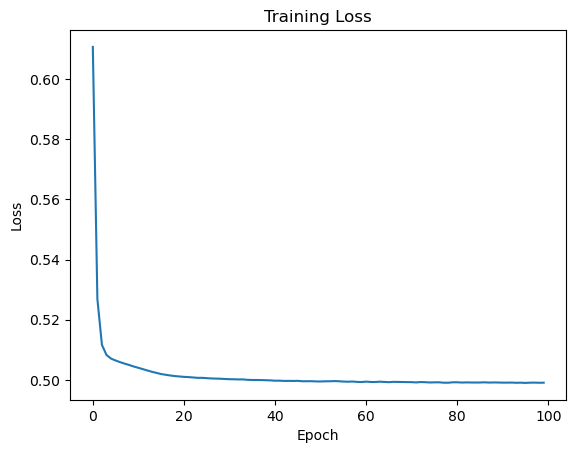

In [20]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [21]:
model.eval()

with torch.no_grad():

    logits = model(X_test_tensor)

    probabilities = torch.sigmoid(logits)

    predictions = (
        probabilities >= 0.5
    ).float()

In [22]:
accuracy = accuracy_score(
    y_test,
    predictions.numpy().flatten()
)

print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.7531


In [23]:
auc = roc_auc_score(
    y_test,
    probabilities.numpy().flatten()
)

print(f"ROC-AUC: {auc:.4f}")

ROC-AUC: 0.8304


In [24]:
cm = confusion_matrix(
    y_test,
    predictions.numpy().flatten()
)

print(cm)

[[4982 2088]
 [1403 5666]]
